In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold0_05["fold"] = [0 for i in range(len(fold0_05))]
fold0_05["target"] = [-0.5 for i in range(len(fold0_05))]

In [3]:
fold1_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold1_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold1_05["fold"] = [1 for i in range(len(fold1_05))]
fold1_05["target"] = [-0.5 for i in range(len(fold1_05))]

In [4]:
fold2_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold2_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold2_05["fold"] = [2 for i in range(len(fold2_05))]
fold2_05["target"] = [-0.5 for i in range(len(fold2_05))]

In [5]:
fold3_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold3_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold3_05["fold"] = [3 for i in range(len(fold3_05))]
fold3_05["target"] = [-0.5 for i in range(len(fold3_05))]

In [6]:
fold4_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold4_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold4_05["fold"] = [4 for i in range(len(fold4_05))]
fold4_05["target"] = [-0.5 for i in range(len(fold4_05))]

In [7]:
fold5_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold5_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold5_05["fold"] = [5 for i in range(len(fold5_05))]
fold5_05["target"] = [-0.5 for i in range(len(fold5_05))]

In [8]:
fold6_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold6_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold6_05["fold"] = [6 for i in range(len(fold6_05))]
fold6_05["target"] = [-0.5 for i in range(len(fold6_05))]

In [9]:
fold7_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold7_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold7_05["fold"] = [7 for i in range(len(fold7_05))]
fold7_05["target"] = [-0.5 for i in range(len(fold7_05))]

In [10]:
df = pd.concat([fold0_05, fold1_05, fold2_05,
                fold3_05, fold4_05, fold5_05,
                fold6_05, fold7_05,], ignore_index=True)

In [11]:
len(df)

406

In [12]:
df["URQ_delta"] = df["URQ_result"] - df["URQ_init"]

In [13]:
df = df[df["URQ_delta"] < 0.0]

In [14]:
len(df)

352

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
def canonicalize(ori):
    # Flip strand = replace + <-> -
    flipped = ori.replace("+", "x").replace("-", "+").replace("x", "-")
    # Pick lexicographically smaller string as canonical
    return min(ori, flipped)

In [17]:
df["orientation_canonical"] = df["orientation"].apply(canonicalize)

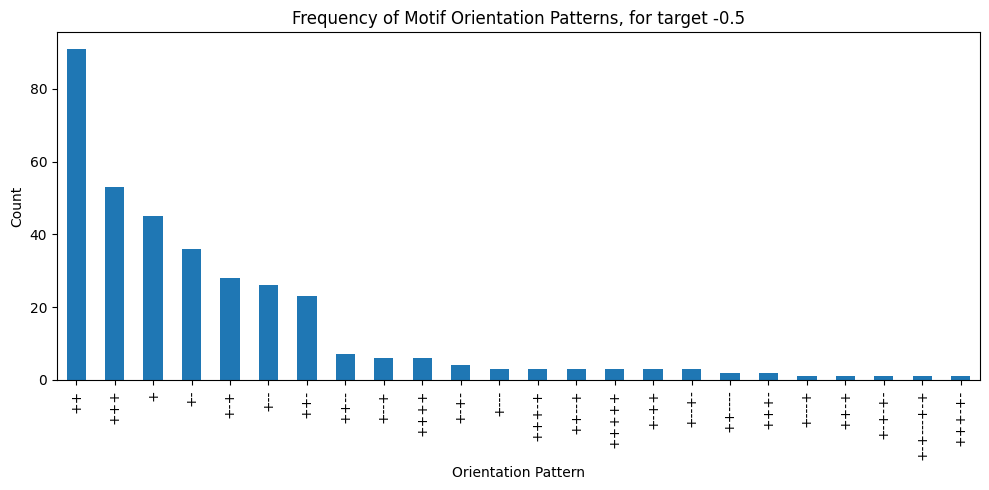

In [18]:
orientation_counts = df[df['orientation'] != "no"]['orientation_canonical'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern")
plt.ylabel("Count")
plt.title("Frequency of Motif Orientation Patterns, for target -0.5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [19]:
df_melted = df.melt(value_vars=['URQ_init', 'URQ_result'], var_name='Type', value_name='URQ mean')

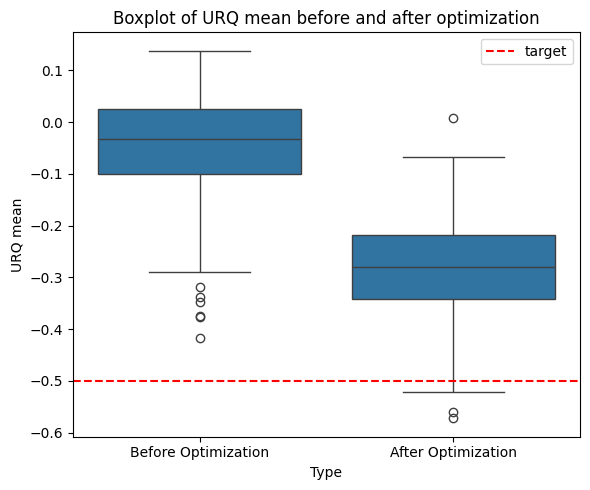

In [20]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Type', y='URQ mean', data=df_melted)
plt.axhline(y=-0.5, color='red', linestyle='--', linewidth=1.5, label='target')
plt.xticks([0, 1], ['Before Optimization', 'After Optimization'])
plt.title('Boxplot of URQ mean before and after optimization')
plt.legend()
plt.tight_layout()
plt.show()

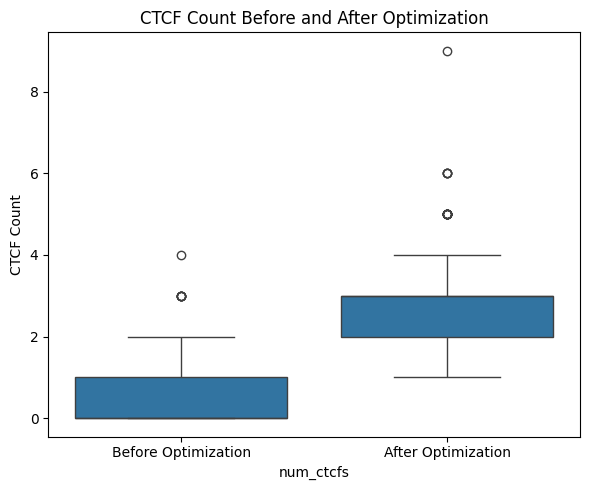

In [21]:
df_box_melted = df.melt(value_vars=['init_CTCFs_num', 'CTCFs_num'],
                            var_name='num_ctcfs', value_name='CTCF Count')

# Rename the categories for clarity
label_map = {
    'init_CTCFs_num': 'Before Optimization',
    'CTCFs_num': 'After Optimization'
}
df_box_melted['num_ctcfs'] = df_box_melted['num_ctcfs'].map(label_map)

# Plotting
plt.figure(figsize=(6, 5))
sns.boxplot(x='num_ctcfs', y='CTCF Count', data=df_box_melted)
plt.title('CTCF Count Before and After Optimization')
plt.tight_layout()
plt.show()

In [22]:
from scipy import stats

### GC content (the entire DNA seq)

In [23]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["GC_seq"], df["last_accepted_step"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["GC_seq"], df["last_accepted_step"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = -0.033, p = 5.406e-01
Spearman r = -0.006, p = 9.050e-01


/tmp/SLURM_2083474/ipykernel_754968/4020890856.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


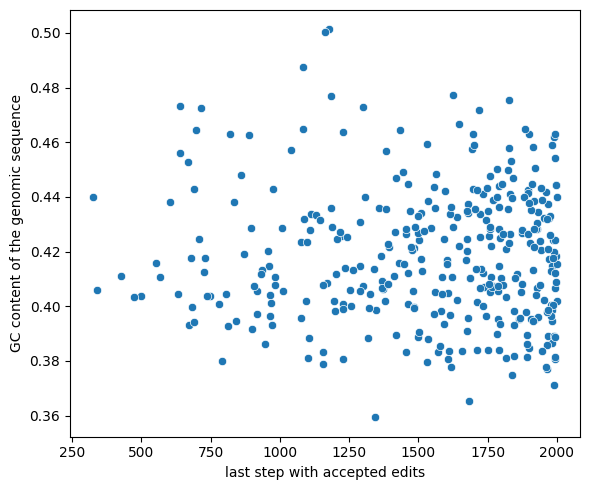

In [24]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='last_accepted_step',
    y='GC_seq',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('last step with accepted edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [25]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["GC_seq"], df["num_edits"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["GC_seq"], df["num_edits"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.138, p = 9.609e-03
Spearman r = 0.142, p = 7.704e-03


/tmp/SLURM_2083474/ipykernel_754968/653908346.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


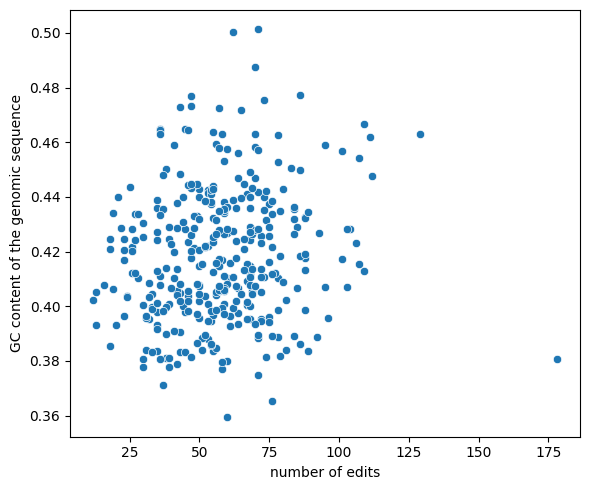

In [26]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='num_edits',
    y='GC_seq',
    data=df,
    palette={True: 'blue', False: 'red'}
)

plt.xlabel('number of edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [27]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["GC_seq"], df["URQ_result"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["GC_seq"], df["URQ_result"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.137, p = 1.034e-02
Spearman r = 0.124, p = 2.025e-02


/tmp/SLURM_2083474/ipykernel_754968/2882479699.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


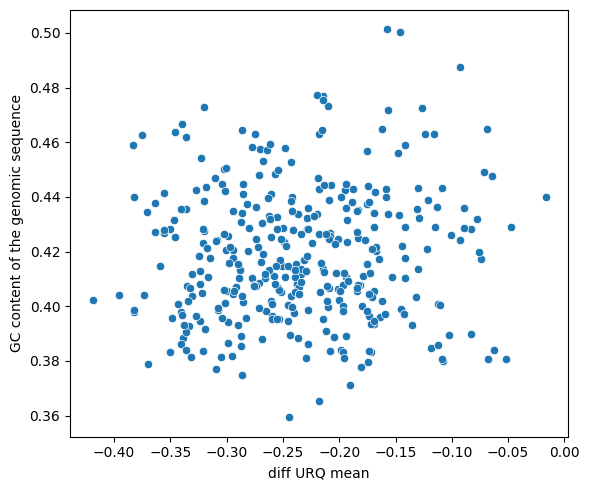

In [28]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='URQ_delta',
    y='GC_seq',
    data=df,
    palette={True: 'blue', False: 'red'}
)

plt.xlabel('diff URQ mean')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

/tmp/SLURM_2083474/ipykernel_754968/14107780.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


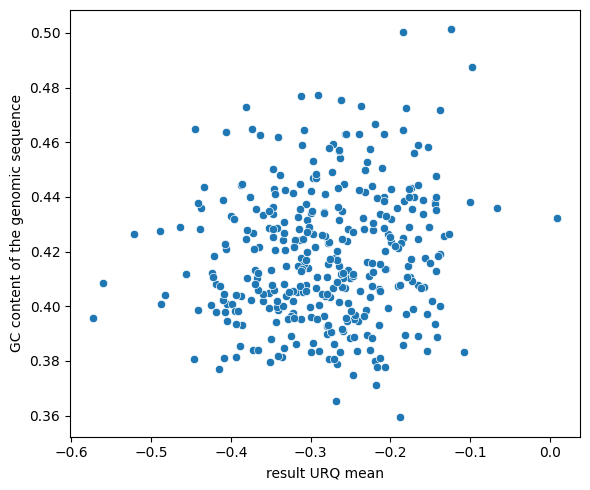

In [29]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='URQ_result',
    y='GC_seq',
    data=df,
    palette={True: 'blue', False: 'red'}
)

plt.xlabel('result URQ mean')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

/tmp/SLURM_2083474/ipykernel_754968/539498842.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


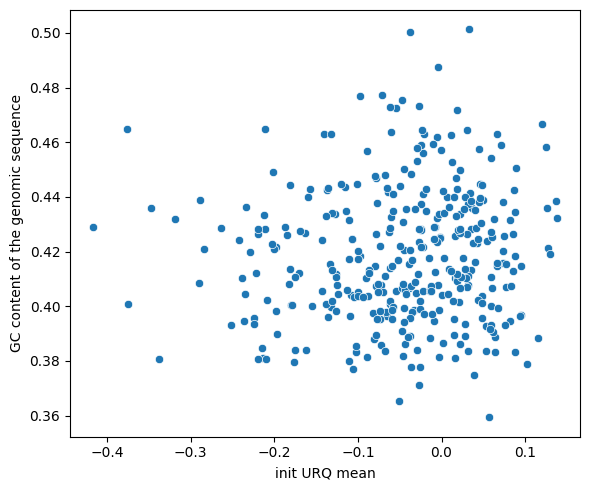

In [30]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='URQ_init',
    y='GC_seq',
    data=df,
    palette={True: 'blue', False: 'red'}
)

plt.xlabel('init URQ mean')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

### Active chromatin fraction

In [31]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["active_fraction"], df["last_accepted_step"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["active_fraction"], df["last_accepted_step"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = -0.050, p = 3.533e-01
Spearman r = -0.043, p = 4.172e-01


/tmp/SLURM_2083474/ipykernel_754968/3030500750.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


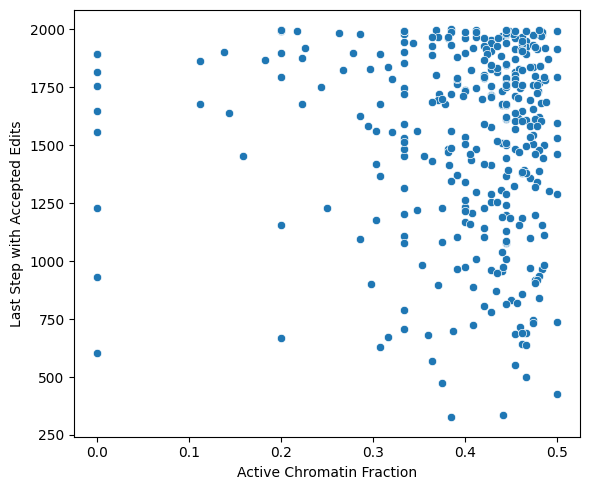

In [32]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='last_accepted_step',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()


In [33]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["active_fraction"], df["num_edits"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["active_fraction"], df["num_edits"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = -0.003, p = 9.532e-01
Spearman r = -0.029, p = 5.877e-01


/tmp/SLURM_2083474/ipykernel_754968/2400073733.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


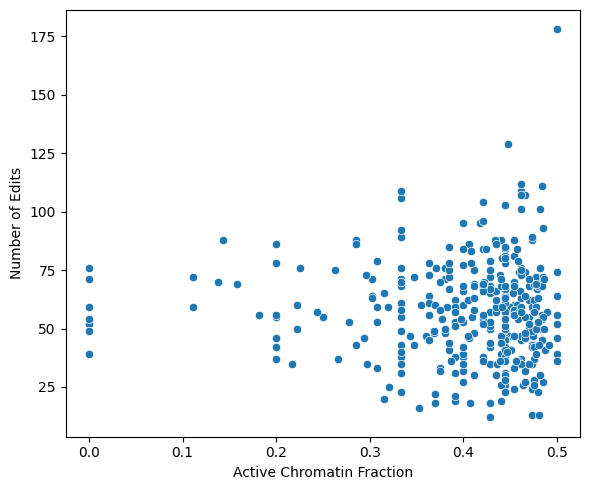

In [34]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='num_edits',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Number of Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [35]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["active_fraction"], df["URQ_result"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["active_fraction"], df["URQ_result"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = -0.061, p = 2.574e-01
Spearman r = -0.092, p = 8.311e-02


/tmp/SLURM_2083474/ipykernel_754968/2544241141.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


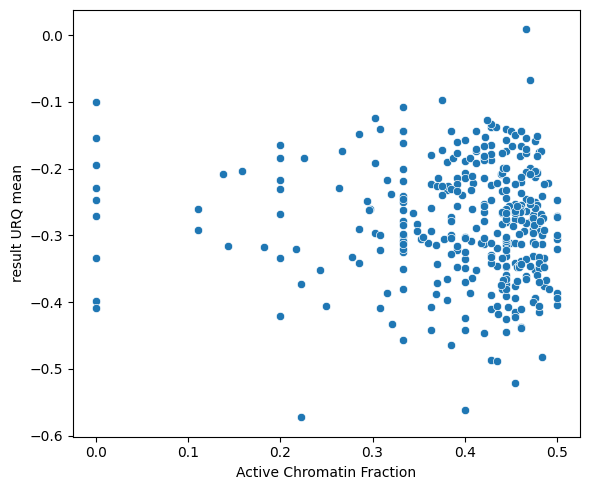

In [36]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='URQ_result',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('result URQ mean')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

### Neutral chromtin fraction

In [37]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["neutral_fraction"], df["last_accepted_step"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["neutral_fraction"], df["last_accepted_step"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.030, p = 5.734e-01
Spearman r = 0.119, p = 2.606e-02


/tmp/SLURM_2083474/ipykernel_754968/1011199811.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


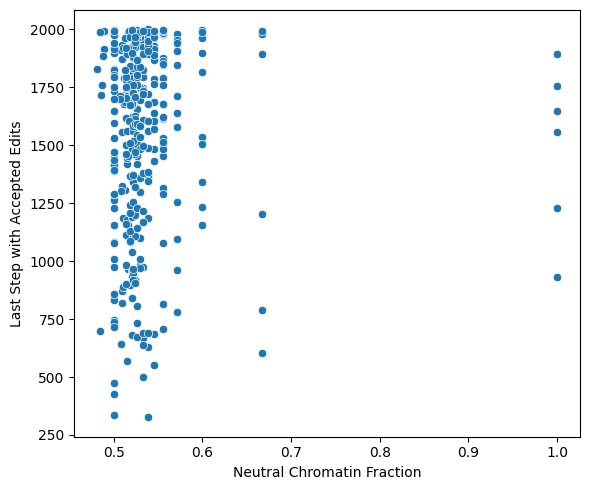

In [38]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='last_accepted_step',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [39]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["neutral_fraction"], df["num_edits"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["neutral_fraction"], df["num_edits"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = -0.006, p = 9.083e-01
Spearman r = 0.021, p = 6.946e-01


/tmp/SLURM_2083474/ipykernel_754968/965045535.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


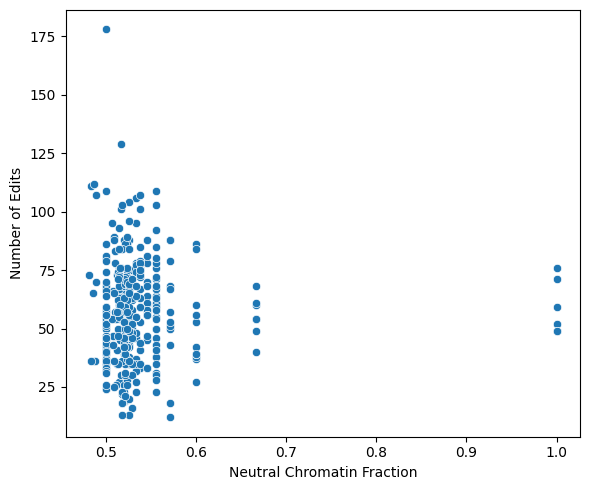

In [40]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='num_edits',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Number of Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [41]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["neutral_fraction"], df["URQ_result"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["neutral_fraction"], df["URQ_result"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.037, p = 4.833e-01
Spearman r = 0.015, p = 7.794e-01


/tmp/SLURM_2083474/ipykernel_754968/2064859718.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


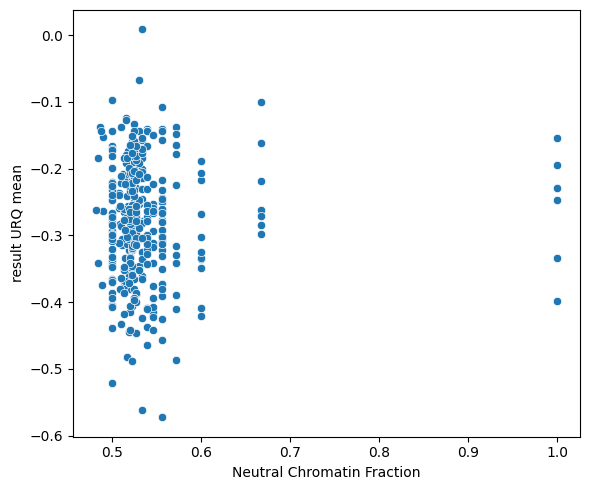

In [42]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='URQ_result',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('result URQ mean')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

### Repressive chromatin fraction

In [43]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["repressive_fraction"], df["last_accepted_step"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["repressive_fraction"], df["last_accepted_step"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.037, p = 4.851e-01
Spearman r = 0.006, p = 9.106e-01


/tmp/SLURM_2083474/ipykernel_754968/3672053279.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


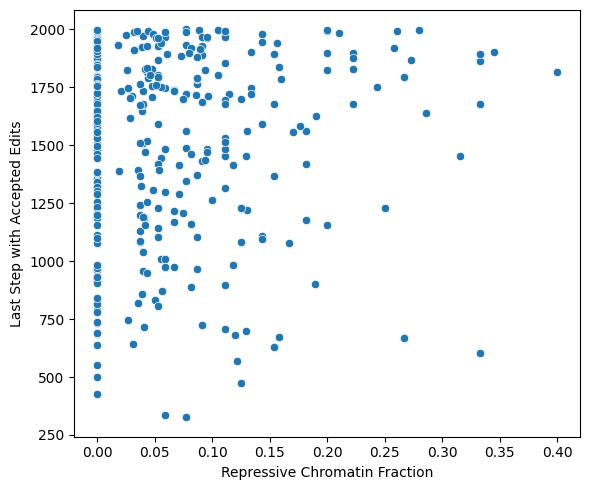

In [44]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='last_accepted_step',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [45]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["repressive_fraction"], df["num_edits"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["repressive_fraction"], df["num_edits"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.010, p = 8.590e-01
Spearman r = 0.035, p = 5.097e-01


/tmp/SLURM_2083474/ipykernel_754968/1083932211.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


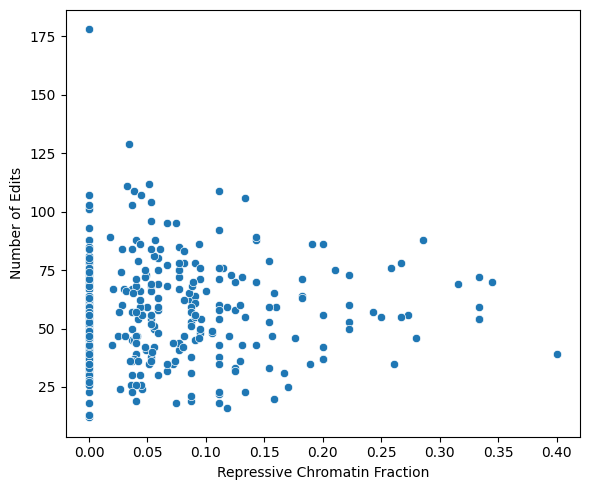

In [46]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='num_edits',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Number of Edits')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [47]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["repressive_fraction"], df["URQ_result"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["repressive_fraction"], df["URQ_result"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.045, p = 4.014e-01
Spearman r = 0.062, p = 2.459e-01


/tmp/SLURM_2083474/ipykernel_754968/2212289600.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


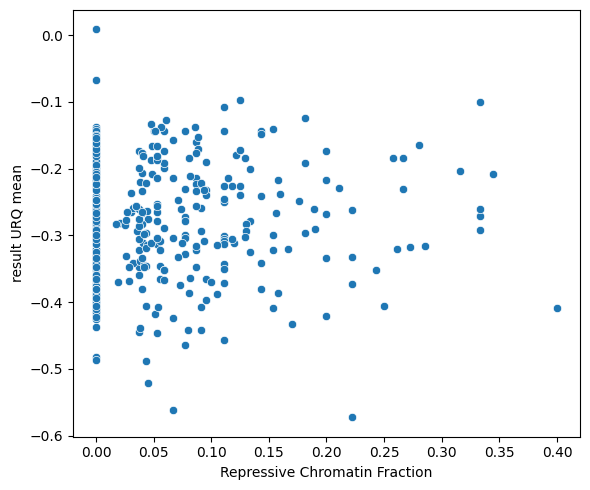

In [48]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='URQ_result',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('result URQ mean')
# plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

### GC content of an edited slice

In [49]:
from scipy.stats import ttest_rel

In [50]:
t_stat, p_val = ttest_rel(df['GC_slice'], df['GC_slice_edited'])

In [51]:
t_stat, p_val

(-25.045098681255176, 3.99669827338686e-80)

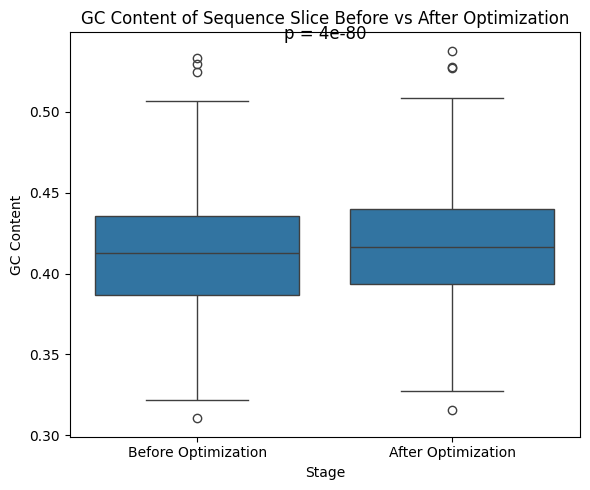

In [52]:
# Melt the DataFrame for plotting
df_gc_melted = df.melt(value_vars=['GC_slice', 'GC_slice_edited'],
                          var_name='Stage', value_name='GC Content')

# Rename the stages for clarity
stage_map = {
    'GC_slice': 'Before Optimization',
    'GC_slice_edited': 'After Optimization'
}
df_gc_melted['Stage'] = df_gc_melted['Stage'].map(stage_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Stage', y='GC Content', data=df_gc_melted)
plt.title('GC Content of Sequence Slice Before vs After Optimization')
plt.text(0.5, max(df_gc_melted['GC Content']) + 0.005,
         f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

In [53]:
before = df_gc_melted.loc[df_gc_melted["Stage"]=="Before Optimization", "GC Content"]
after  = df_gc_melted.loc[df_gc_melted["Stage"]=="After Optimization", "GC Content"]

mean_diff = after.mean() - before.mean()
pooled_sd = np.sqrt(((before.std()**2 + after.std()**2) / 2))
cohens_d = mean_diff / pooled_sd

print(f"Mean difference = {mean_diff:.4f}")
print(f"Cohen's d = {cohens_d:.3f}")

Mean difference = 0.0045
Cohen's d = 0.120


### Test / Valid / Train Split

In [54]:
# Map folds to dataset type
def map_set(fold):
    if fold == 0:
        return "Test"
    elif fold == 1:
        return "Valid"
    else:
        return "Train"

df["set"] = df["fold"].apply(map_set)

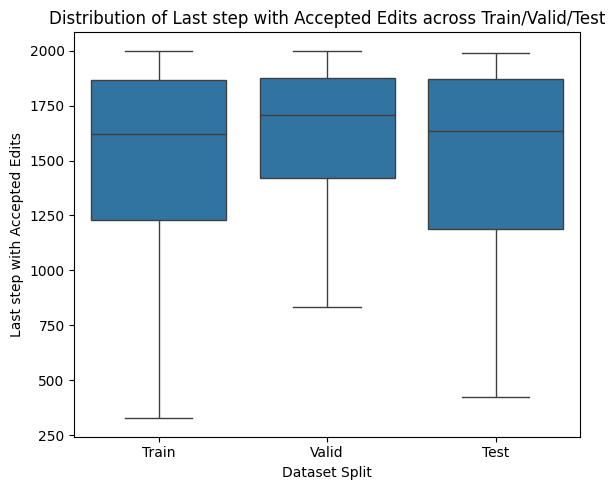

In [55]:
# Make the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(
    x="set", 
    y="last_accepted_step", 
    data=df,
    order=["Train", "Valid", "Test"]  # ensure consistent ordering
)

plt.xlabel("Dataset Split")
plt.ylabel("Last step with Accepted Edits")
plt.title("Distribution of Last step with Accepted Edits across Train/Valid/Test")
plt.tight_layout()
plt.show()

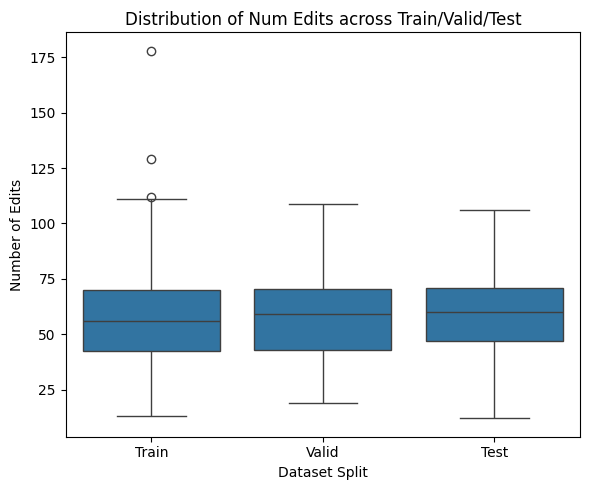

In [56]:
# Make the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(
    x="set", 
    y="num_edits", 
    data=df,
    order=["Train", "Valid", "Test"]  # ensure consistent ordering
)

plt.xlabel("Dataset Split")
plt.ylabel("Number of Edits")
plt.title("Distribution of Num Edits across Train/Valid/Test")
plt.tight_layout()
plt.show()

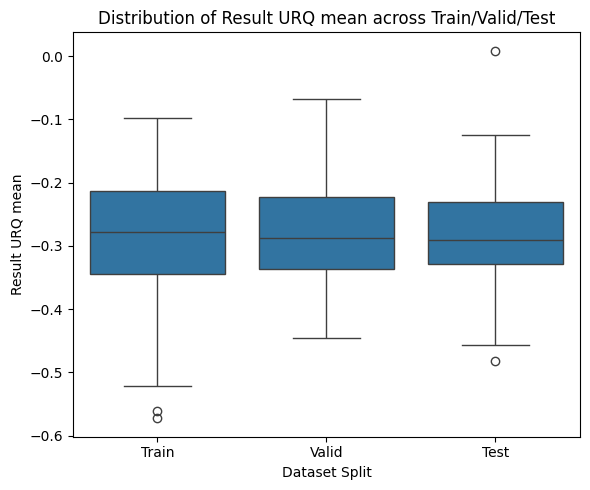

In [57]:
# Make the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(
    x="set", 
    y="URQ_result", 
    data=df,
    order=["Train", "Valid", "Test"]  # ensure consistent ordering
)

plt.xlabel("Dataset Split")
plt.ylabel("Result URQ mean")
plt.title("Distribution of Result URQ mean across Train/Valid/Test")
plt.tight_layout()
plt.show()

### Uniqueness of the Generated Slices

In [58]:
import torch

In [59]:
TARGET_C = -0.5

In [ ]:
sequences = []
for _, row in df.iterrows():
    path = f"/scratch1/smaruj/generate_genomic_boundary/results/target_{TARGET_C}/fold{row['fold']}/{row['chrom']}_{row['centered_start']}_{row['centered_end']}_slice.pt"
    arr = torch.load(path)  # shape: (1, 4, 2048)
    arr = arr.squeeze(0)
    seq = "".join("ACGT"[i] for i in arr.argmax(0).tolist())
    sequences.append(seq)

In [ ]:
df["sequence"] = sequences

In [ ]:
n_unique = df["sequence"].nunique()
print(f"Out of {len(df)} sequences, {n_unique} are unique.")

### Uniqueness of the generated CTCF motifs (+15bp flanks)

In [60]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [61]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [62]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [63]:
from tangermeme.tools import fimo

In [ ]:
ctcf_scan_flank = 15

In [ ]:
bin_size = 2048
cropping_applied = 64
padding_bins = 0
padding = padding_bins * bin_size

slice_0_bins = [256]
slice_0_start = (min(slice_0_bins) + cropping_applied - padding_bins) * bin_size
slice_0_end = (max(slice_0_bins) + 1 + cropping_applied + padding_bins) * bin_size

In [64]:
import random

In [ ]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    input_sequence = np.expand_dims(one_hot_encoded, axis=0)

    return input_sequence

In [65]:
from pyfaidx import Fasta

In [66]:
fasta_file = "/project2/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [67]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
def one_hot_decode_sequence(one_hot_array):
    """
    Decode a one-hot encoded sequence back to a DNA string.

    Args:
        one_hot_array (np.ndarray or torch.Tensor): shape (4, L)
    
    Returns:
        str: DNA sequence
    """
    # Convert torch tensor to numpy if needed
    if isinstance(one_hot_array, torch.Tensor):
        one_hot_array = one_hot_array.cpu().numpy()

    # Define mapping from index to base
    int_to_base = {0: 'A', 1: 'C', 2: 'G', 3: 'T'}

    # Find the index of the max along axis 0 (the "hot" base)
    indices = np.argmax(one_hot_array, axis=0)

    # Convert indices to bases
    sequence = ''.join([int_to_base[i] for i in indices])

    return sequence

In [ ]:
ctcf_sequences_list = []
flank = 15  # +/- bp around the motif

for row in df.itertuples(index=False):
    chrom, pred_start, pred_end = row.chrom, row.centered_start, row.centered_end
    sequence = genome[chrom][pred_start:pred_end]

    X = one_hot_encode_sequence(sequence)
    X_tensor = torch.tensor(X)

    # modifying X
    X_mod = X_tensor.clone()

    mod_slice = torch.load(
        f"/scratch1/smaruj/generate_genomic_boundary/results/target_-0.5/fold{row.fold}/{chrom}_{pred_start}_{pred_end}_slice.pt",
        map_location=device
    )

    X_mod[0, :, slice_0_start:slice_0_end] = mod_slice[0, :, :]

    slice_to_scan = X_mod[:, :, slice_0_start-ctcf_scan_flank:slice_0_end+ctcf_scan_flank]

    hits = fimo.fimo(
        motifs=motifs_dict,
        sequences=slice_to_scan,
        threshold=1e-4,
        reverse_complement=True
    )[0]

    # Adjust positions to original X_mod coordinates
    hits["start"] -= ctcf_scan_flank
    hits["end"] -= ctcf_scan_flank

    # Collect sequences with ±flank
    for s, e in zip(hits["start"], hits["end"]):
        s_flank = max(0, s - flank)
        e_flank = min(len(sequence), e + flank)  # ensure we don't go out of bounds
        motif_seq_onehot = X_mod[0, :, s_flank:e_flank].detach().cpu().numpy()
        motif_seq_str = one_hot_decode_sequence(motif_seq_onehot)  # implement this if not already
        ctcf_sequences_list.append(motif_seq_str)


In [ ]:
# Summary statistics
total_ctcf = len(ctcf_sequences_list)
unique_ctcf = len(set(ctcf_sequences_list))

print(f"Total CTCF occurrences: {total_ctcf}")
print(f"Unique CTCF sequences (with flanks): {unique_ctcf}")

### CTCF-like content

In [68]:
from pyfaidx import Fasta

In [69]:
from tqdm import tqdm

In [70]:
fasta_file = "/project2/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [71]:
def get_sequence(genome, chrom, start, end):
    seq = genome[chrom][start:end].seq.upper()
    return seq

In [72]:
def reverse_complement(seq: str) -> str:
    complement = str.maketrans("ACGTN", "TGCAN")  # include N if needed
    return seq.translate(complement)[::-1]

In [73]:
len(df)

352

In [74]:
# estimating background probabilities - all genomic regions with successful optimizations

from collections import Counter

# Initialize counter
total_counts = Counter()
total_bases = 0

for _, row in df.iterrows():
    # read sequence from genome
    seq = get_sequence(genome, row["chrom"], row["centered_start"], row["centered_end"])
    seq = seq.upper()
    
    # count nucleotides in this sequence
    counts = Counter(seq)
    
    # keep only A/C/G/T
    for b in "ACGT":
        total_counts[b] += counts.get(b, 0)
    
    # accumulate total base count
    total_bases += sum(counts[b] for b in "ACGT")

# calculate background probabilities
bg_probs = {b: total_counts[b] / total_bases for b in "ACGT"}
print("Estimated background probabilities:", bg_probs)

Estimated background probabilities: {'A': 0.2906737955707097, 'C': 0.20934592401496138, 'G': 0.20922984982597, 'T': 0.2907504305883589}


In [75]:
def seq_score(seq, pwm, bg=None, pseudocount=1e-9):
    """
    seq: DNA sequence (string)
    pwm: numpy array of shape (length, 4)
    bg: dict of background probabilities, e.g., {'A':0.29, 'C':0.21, 'G':0.21, 'T':0.29}
    pseudocount: small value to avoid log(0)
    """
    if bg is None:
        bg = {'A':0.25, 'C':0.25, 'G':0.25, 'T':0.25}

    base_idx = {'A':0, 'C':1, 'G':2, 'T':3}
    score = 0.0
    seq = seq.upper()
    
    for i, b in enumerate(seq):
        if b not in base_idx:
            continue  # skip Ns or unexpected bases
        p = pwm[i, base_idx[b]]
        p = max(p, pseudocount)
        score += np.log2(p / bg[b])  # use bg for this base
    return score

In [76]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [77]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [78]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)

In [79]:
# Reverse one-hot encoding
def ohe_to_seq(ohe_tensor):
    bases = np.array(['A', 'C', 'G', 'T'])
    # ohe_tensor shape (1, 4, L)
    ohe = ohe_tensor.squeeze(0).cpu().detach().numpy()  # (4, L)
    seq_idx = np.argmax(ohe, axis=0)
    return ''.join(bases[seq_idx])

In [80]:
# Sliding score calculation
def sliding_scores(seq, pwm, step=1):
    window = pwm.shape[0]
    scores = []
    for i in range(0, len(seq) - window + 1, step):
        window_seq = seq[i:i+window]
        score = seq_score(window_seq, pwm)
        scores.append(score)
    return np.array(scores)

In [81]:
def reverse_complement_pwm(pwm):
    # Columns: 0:A, 1:C, 2:G, 3:T
    rev_pwm = pwm[::-1, :].copy()
    rev_pwm = rev_pwm[:, [3, 2, 1, 0]]  # swap A↔T and C↔G
    return rev_pwm

In [82]:
pwm_CTCF_rc = reverse_complement_pwm(pwm_CTCF)

In [84]:
# Iterate over table

# Initialize new columns with default values
df['num_positive_peaks'] = 0
df['sum_positive_scores'] = 0.0
df['max_CTCF_score'] = 0.0

for i, row in tqdm(df.iterrows(), total=len(df)):
    chrom = row["chrom"]
    start = row["centered_start"]
    end = row["centered_end"]
    fold = row["fold"]
    
    seq = get_sequence(genome, chrom, start + 655360 - 9, start + 657408 + 9)
    
    # Compute sliding scores
    scores = sliding_scores(seq, pwm_CTCF, step=1)
    
    # Sliding scan reverse
    scores_rev = sliding_scores(seq, pwm_CTCF_rc, step=1)
    
    scores_combined = np.maximum(scores, scores_rev)
    
    # Compute summary stats
    positive_mask = scores_combined > 0
    num_positive_peaks = int(np.sum(positive_mask))
    sum_positive_scores = float(np.sum(scores_combined[positive_mask]))
    max_score = float(np.max(scores_combined))  # maximum score
    
    # Add stats to df
    df.at[i, 'num_positive_peaks'] = num_positive_peaks
    df.at[i, 'sum_positive_scores'] = sum_positive_scores
    df.at[i, 'max_CTCF_score'] = max_score
    
    # print("num of peaks", num_positive_peaks)
    # print("sum", sum_positive_scores)
    
    # x = np.arange(len(scores))
    
    # plt.figure(figsize=(8, 4))
    # plt.plot(x, scores, label="Forward", color="steelblue")
    # plt.plot(x, scores_rev, label="Reverse complement", color="tomato")
    
    # plt.title(f"{row['chrom']}:{row['centered_start']}-{row['centered_end']}  (fold {row['fold']})")
    # plt.xlabel("Position relative to optimized region (bp)")
    # plt.ylabel("CTCF-like information score")
    # plt.legend()
    # plt.tight_layout()
    # plt.show()
    

100%|██████████| 352/352 [00:25<00:00, 14.08it/s]


/tmp/SLURM_2083474/ipykernel_754968/4097636045.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


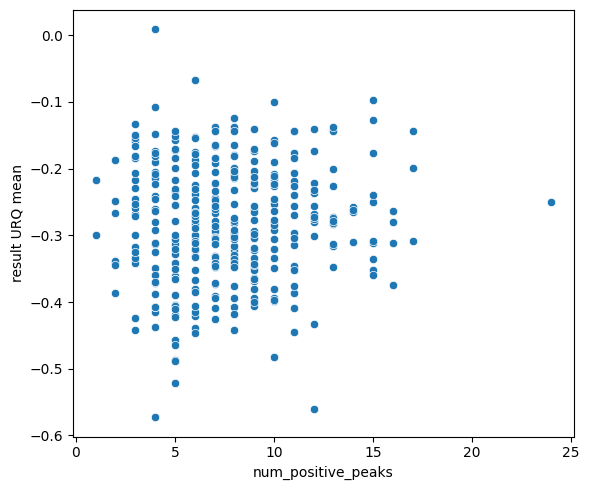

In [85]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='num_positive_peaks',
    y='URQ_result',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('num_positive_peaks')
plt.ylabel('result URQ mean')
plt.tight_layout()
plt.show()

In [86]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["num_positive_peaks"], df["URQ_result"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["num_positive_peaks"], df["URQ_result"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.071, p = 1.808e-01
Spearman r = 0.060, p = 2.643e-01


/tmp/SLURM_2083474/ipykernel_754968/2978540815.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


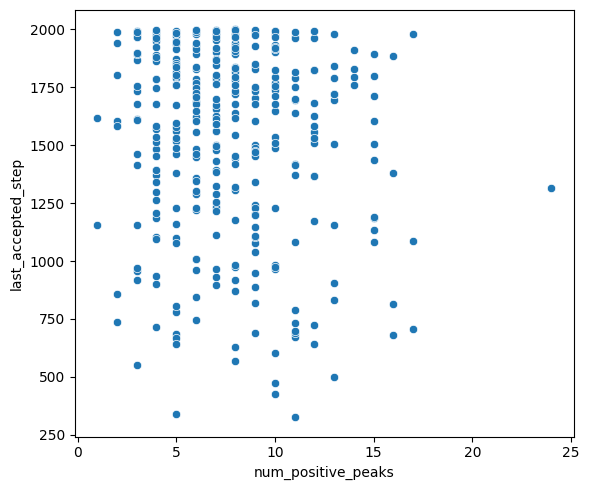

In [87]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='num_positive_peaks',
    y='last_accepted_step',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('num_positive_peaks')
plt.ylabel('last_accepted_step')
plt.tight_layout()
plt.show()

In [88]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["num_positive_peaks"], df["last_accepted_step"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["num_positive_peaks"], df["last_accepted_step"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = -0.101, p = 5.717e-02
Spearman r = -0.085, p = 1.135e-01


/tmp/SLURM_2083474/ipykernel_754968/1880145419.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


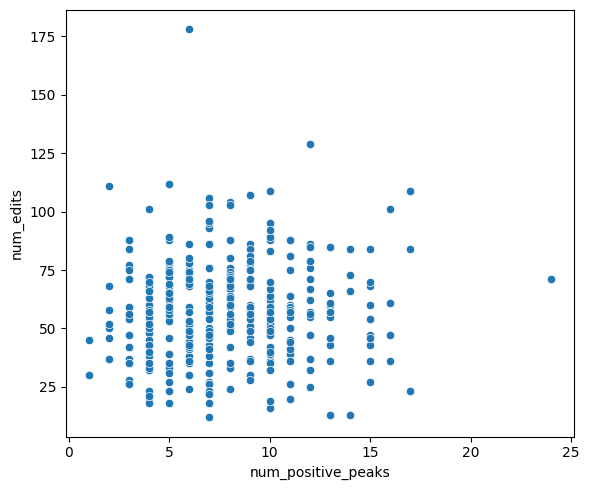

In [89]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='num_positive_peaks',
    y='num_edits',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('num_positive_peaks')
plt.ylabel('num_edits')
plt.tight_layout()
plt.show()

In [90]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["num_positive_peaks"], df["num_edits"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["num_positive_peaks"], df["num_edits"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.079, p = 1.412e-01
Spearman r = 0.095, p = 7.557e-02


/tmp/SLURM_2083474/ipykernel_754968/2247070371.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


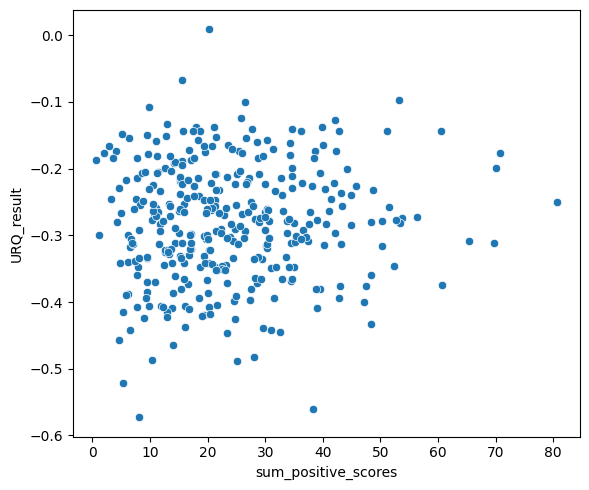

In [91]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='sum_positive_scores',
    y='URQ_result',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('sum_positive_scores')
plt.ylabel('URQ_result')
plt.tight_layout()
plt.show()

In [92]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["sum_positive_scores"], df["URQ_result"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["sum_positive_scores"], df["URQ_result"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.069, p = 1.992e-01
Spearman r = 0.052, p = 3.293e-01


/tmp/SLURM_2083474/ipykernel_754968/760016951.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


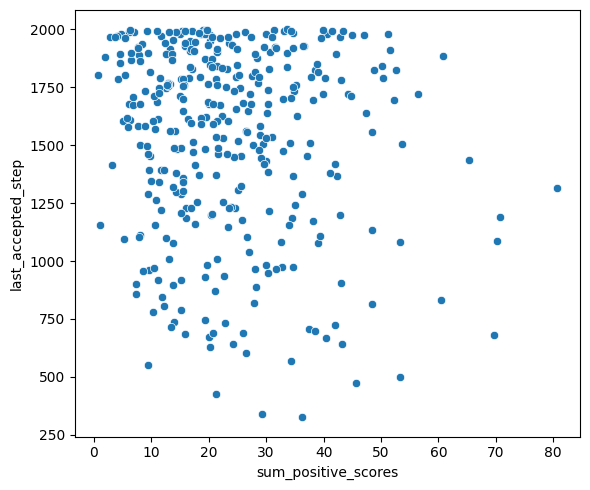

In [93]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='sum_positive_scores',
    y='last_accepted_step',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('sum_positive_scores')
plt.ylabel('last_accepted_step')
plt.tight_layout()
plt.show()

In [94]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["sum_positive_scores"], df["last_accepted_step"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["sum_positive_scores"], df["last_accepted_step"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = -0.111, p = 3.801e-02
Spearman r = -0.070, p = 1.932e-01


/tmp/SLURM_2083474/ipykernel_754968/1460534121.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


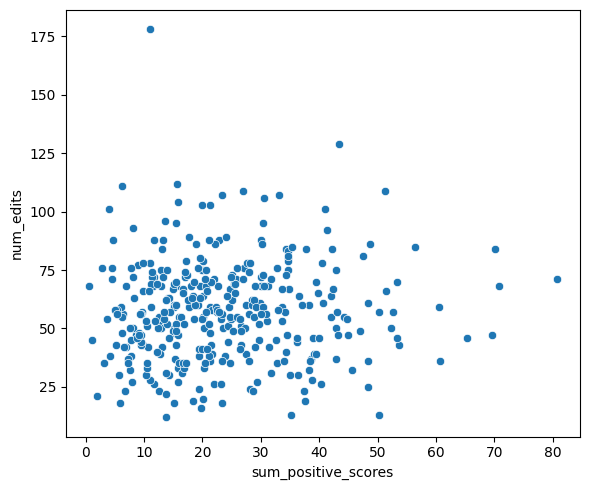

In [95]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='sum_positive_scores',
    y='num_edits',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('sum_positive_scores')
plt.ylabel('num_edits')
plt.tight_layout()
plt.show()

In [96]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["sum_positive_scores"], df["num_edits"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["sum_positive_scores"], df["num_edits"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.051, p = 3.410e-01
Spearman r = 0.073, p = 1.745e-01


/tmp/SLURM_2083474/ipykernel_754968/4191943602.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


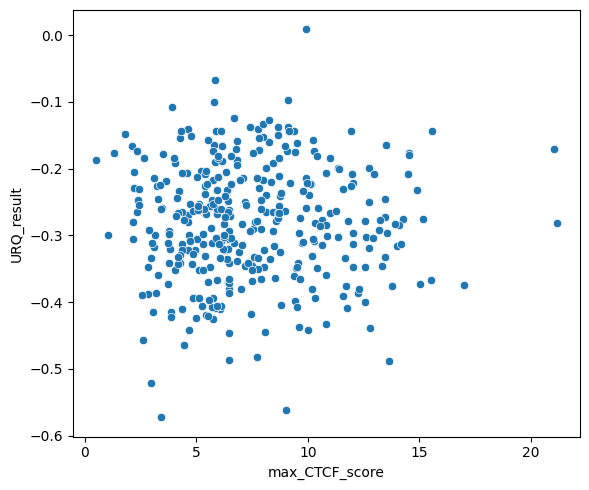

In [98]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='max_CTCF_score',
    y='URQ_result',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('max_CTCF_score')
plt.ylabel('URQ_result')
plt.tight_layout()
plt.show()

In [99]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["max_CTCF_score"], df["URQ_result"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["max_CTCF_score"], df["URQ_result"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = 0.021, p = 6.997e-01
Spearman r = 0.020, p = 7.098e-01


/tmp/SLURM_2083474/ipykernel_754968/3653865294.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


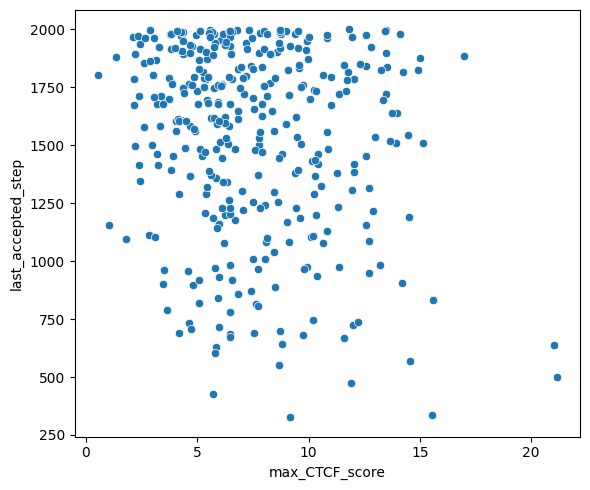

In [100]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='max_CTCF_score',
    y='last_accepted_step',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('max_CTCF_score')
plt.ylabel('last_accepted_step')
plt.tight_layout()
plt.show()

In [101]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["max_CTCF_score"], df["last_accepted_step"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["max_CTCF_score"], df["last_accepted_step"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = -0.167, p = 1.704e-03
Spearman r = -0.123, p = 2.098e-02


/tmp/SLURM_2083474/ipykernel_754968/1869214102.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


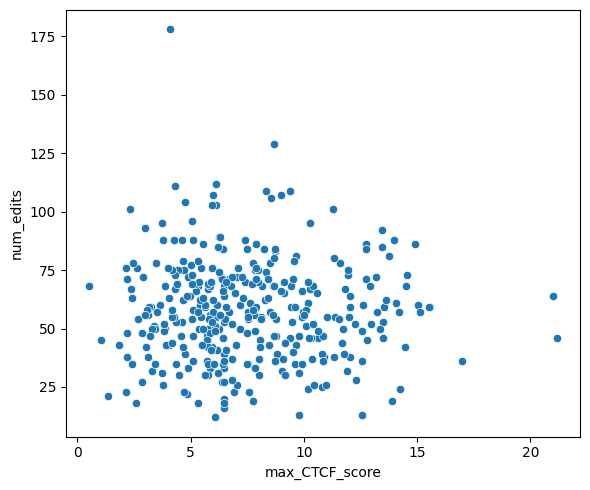

In [102]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='max_CTCF_score',
    y='num_edits',
    data=df,
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('max_CTCF_score')
plt.ylabel('num_edits')
plt.tight_layout()
plt.show()

In [103]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df["max_CTCF_score"], df["num_edits"])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df["max_CTCF_score"], df["num_edits"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3e}")

Pearson r = -0.019, p = 7.250e-01
Spearman r = -0.014, p = 7.873e-01
